In [1]:
import pandapower as pp
import pandapower.networks as pp_net
import numpy as np

import seaborn as sb
import pandas as pd

from probabilistic_models.opearations.demand_sampler import simple_demand_sampler

In [17]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pandapower as pp
import pandapower.networks as pp_net


# ============================================================
# 1. Obtain the baseline optimal dispatch
# ============================================================

net = pp_net.case24_ieee_rts()

pp.runopp(
    net,
    calculate_voltage_angles=True,
    init="flat",
    delta=1e-8,
    verbose=False,
)

if not net.OPF_converged:
    raise RuntimeError("The baseline OPF did not converge.")

# Transfer only the OPF setpoints.
# Do not use `net.gen = net.res_gen`, because the two tables have
# different meanings and different columns.
net.gen.loc[:, "p_mw"] = net.res_gen["p_mw"].to_numpy()
net.gen.loc[:, "vm_pu"] = net.res_gen["vm_pu"].to_numpy()

# Re-run a standard power flow using the fixed OPF dispatch.
pp.runpp(
    net,
    calculate_voltage_angles=True,
    init="results",
    enforce_q_lims=True,
    distributed_slack=False,
    numba=False,
)

if not net.converged:
    raise RuntimeError("The baseline fixed-dispatch power flow did not converge.")

# Immutable baseline network used to initialize every scenario.
NET = copy.deepcopy(net)

base_load_p = NET.load["p_mw"].to_numpy(dtype=float).copy()
base_load_q = NET.load["q_mvar"].to_numpy(dtype=float).copy()
base_gen_p = NET.gen["p_mw"].to_numpy(dtype=float).copy()

base_grid_p = float(NET.res_ext_grid["p_mw"].sum())

print(f"Baseline demand:      {base_load_p.sum():.2f} MW")
print(f"Baseline generation:  {base_gen_p.sum():.2f} MW")
print(f"Baseline slack power: {base_grid_p:.2f} MW")
print(
    f"Baseline maximum line loading: "
    f"{NET.res_line['loading_percent'].max():.2f}%"
)


# ============================================================
# 2. Sample demand scenarios
# ============================================================

Load_samples = simple_demand_sampler(
    base_load_p,
    n_samples=300,
    noise_level=0.1,
    fat_tailed=True,
)

Load_samples = np.asarray(Load_samples, dtype=float)

# Accept either:
#   (number of scenarios, number of loads), or
#   (number of loads, number of scenarios)
if Load_samples.shape[1] == len(base_load_p):
    pass
elif Load_samples.shape[0] == len(base_load_p):
    Load_samples = Load_samples.T
else:
    raise ValueError(
        "Load_samples must have shape "
        f"(n_scenarios, {len(base_load_p)}) or "
        f"({len(base_load_p)}, n_scenarios); "
        f"received {Load_samples.shape}."
    )

# Loads cannot be negative.
Load_samples = np.maximum(Load_samples, 0.0)

n_scenarios = Load_samples.shape[0]


# ============================================================
# 3. Fixed-dispatch severity analysis
# ============================================================

VMIN_PU = 0.95
VMAX_PU = 1.05
LINE_LIMIT_PERCENT = 100.0

line_indices = NET.line.index
bus_indices = NET.bus.index

scenario_records = []

line_loading_records = []
line_severity_records = []

bus_voltage_records = []
bus_undervoltage_records = []
bus_overvoltage_records = []


for scenario_id, sampled_p in enumerate(Load_samples):

    # Restore the complete baseline network and its OPF dispatch.
    scenario_net = copy.deepcopy(NET)

    # --------------------------------------------------------
    # Apply sampled active demand
    # --------------------------------------------------------

    scenario_net.load.loc[:, "p_mw"] = sampled_p

    # Preserve the baseline power factor of each load:
    #
    # q_scenario / p_scenario = q_baseline / p_baseline
    #
    load_scaling = np.divide(
        sampled_p,
        base_load_p,
        out=np.ones_like(sampled_p),
        where=np.abs(base_load_p) > 1e-12,
    )

    scenario_net.load.loc[:, "q_mvar"] = base_load_q * load_scaling

    # Explicitly restore the fixed active-power dispatch.
    scenario_net.gen.loc[:, "p_mw"] = base_gen_p

    try:
        # Standard PF: this does not economically redispatch generators.
        pp.runpp(
            scenario_net,
            calculate_voltage_angles=True,
            init="results",
            enforce_q_lims=True,
            distributed_slack=False,
            numba=False,
        )

        if not scenario_net.converged:
            raise pp.LoadflowNotConverged(
                f"Scenario {scenario_id} did not converge."
            )

        # Verify that the non-slack active-power dispatch was unchanged.
        np.testing.assert_allclose(
            scenario_net.gen["p_mw"].to_numpy(dtype=float),
            base_gen_p,
            rtol=0.0,
            atol=1e-9,
        )

        # ----------------------------------------------------
        # Line-overload severity
        # ----------------------------------------------------

        line_loading = (
            scenario_net.res_line["loading_percent"]
            .reindex(line_indices)
            .to_numpy(dtype=float)
        )

        # Severity in percentage points above the thermal limit.
        # Examples:
        #    97% loading -> severity 0
        #   103% loading -> severity 3
        line_overload_severity = np.maximum(
            line_loading - LINE_LIMIT_PERCENT,
            0.0,
        )

        worst_line_position = int(np.argmax(line_loading))
        worst_line_index = line_indices[worst_line_position]

        # ----------------------------------------------------
        # Voltage severity
        # ----------------------------------------------------

        bus_voltage = ( scenario_net.res_bus["vm_pu"].reindex(bus_indices).to_numpy(dtype=float) )
        undervoltage_severity = np.maximum(  VMIN_PU - bus_voltage,  0.0, )
        overvoltage_severity = np.maximum( bus_voltage - VMAX_PU, 0.0, )

        # Combined voltage violation at every bus.
        voltage_severity = ( undervoltage_severity + overvoltage_severity )

        # Convert p.u. deviations to percentage points.
        undervoltage_severity_pct = 100.0 * undervoltage_severity
        overvoltage_severity_pct = 100.0 * overvoltage_severity
        voltage_severity_pct = 100.0 * voltage_severity

        # ----------------------------------------------------
        # Slack/grid response
        # ----------------------------------------------------

        scenario_grid_p = float( scenario_net.res_ext_grid["p_mw"].sum() )

        scenario_records.append({
                "scenario": scenario_id,
                "converged": True,
                "total_demand_mw": sampled_p.sum(),
                "grid_p_mw": scenario_grid_p,
                "grid_delta_mw": scenario_grid_p - base_grid_p,
                "maximum_line_loading_percent": line_loading.max(),
                "worst_line_overload_severity": (
                    line_overload_severity.max()
                ),
                "worst_line_index": worst_line_index,
                "number_overloaded_lines": int(
                    np.count_nonzero(line_overload_severity > 0.0)
                ),
                "total_line_overload_severity": (
                    line_overload_severity.sum()
                ),
                "minimum_voltage_pu": bus_voltage.min(),
                "maximum_voltage_pu": bus_voltage.max(),
                "worst_undervoltage_severity_pct": (
                    undervoltage_severity_pct.max()
                ),
                "worst_overvoltage_severity_pct": (
                    overvoltage_severity_pct.max()
                ),
                "worst_voltage_severity_pct": (
                    voltage_severity_pct.max()
                ),
                "number_voltage_violations": int(
                    np.count_nonzero(voltage_severity > 0.0)
                ),
            }
        )

        line_loading_records.append(line_loading)
        line_severity_records.append(line_overload_severity)

        bus_voltage_records.append(bus_voltage)
        bus_undervoltage_records.append(
            undervoltage_severity_pct
        )
        bus_overvoltage_records.append(
            overvoltage_severity_pct
        )

    except pp.LoadflowNotConverged:

        # Non-convergence must not be interpreted as zero severity.
        scenario_records.append(
            {
                "scenario": scenario_id,
                "converged": False,
                "total_demand_mw": sampled_p.sum(),
                "grid_p_mw": np.nan,
                "grid_delta_mw": np.nan,
                "maximum_line_loading_percent": np.nan,
                "worst_line_overload_severity": np.nan,
                "worst_line_index": None,
                "number_overloaded_lines": np.nan,
                "total_line_overload_severity": np.nan,
                "minimum_voltage_pu": np.nan,
                "maximum_voltage_pu": np.nan,
                "worst_undervoltage_severity_pct": np.nan,
                "worst_overvoltage_severity_pct": np.nan,
                "worst_voltage_severity_pct": np.nan,
                "number_voltage_violations": np.nan,
            }
        )

        nan_lines = np.full(len(line_indices), np.nan)
        nan_buses = np.full(len(bus_indices), np.nan)

        line_loading_records.append(nan_lines.copy())
        line_severity_records.append(nan_lines.copy())

        bus_voltage_records.append(nan_buses.copy())
        bus_undervoltage_records.append(nan_buses.copy())
        bus_overvoltage_records.append(nan_buses.copy())


# ============================================================
# 4. Organize the results
# ============================================================

severity_results = pd.DataFrame(scenario_records).set_index("scenario")

line_loading = pd.DataFrame(
    line_loading_records,
    index=severity_results.index,
    columns=line_indices,
)
line_loading.columns.name = "line"

line_overload_severity = pd.DataFrame(
    line_severity_records,
    index=severity_results.index,
    columns=line_indices,
)
line_overload_severity.columns.name = "line"

bus_voltage = pd.DataFrame(
    bus_voltage_records,
    index=severity_results.index,
    columns=bus_indices,
)
bus_voltage.columns.name = "bus"

bus_undervoltage_severity = pd.DataFrame(
    bus_undervoltage_records,
    index=severity_results.index,
    columns=bus_indices,
)
bus_undervoltage_severity.columns.name = "bus"

bus_overvoltage_severity = pd.DataFrame(
    bus_overvoltage_records,
    index=severity_results.index,
    columns=bus_indices,
)
bus_overvoltage_severity.columns.name = "bus"


# Display scenarios in decreasing severity order.
display(
    severity_results.sort_values(
        [
            "worst_line_overload_severity",
            "worst_voltage_severity_pct",
        ],
        ascending=False,
    )
)

Baseline demand:      2850.00 MW
Baseline generation:  1266.01 MW
Baseline slack power: 1.72 MW
Baseline maximum line loading: 91.38%


,converged,total_demand_mw,grid_p_mw,grid_delta_mw,maximum_line_loading_percent,worst_line_overload_severity,worst_line_index,number_overloaded_lines,total_line_overload_severity,minimum_voltage_pu,maximum_voltage_pu,worst_undervoltage_severity_pct,worst_overvoltage_severity_pct,worst_voltage_severity_pct,number_voltage_violations
scenario,,,,,,,,,,,,,,,
259,True,3079.999813,281.816087,280.097644,181.978709,81.978709,9.0,2.0,89.314161,0.676646,1.056462,27.335406,0.646245,27.335406,14.0
100,True,2537.536039,-261.292168,-263.010611,179.829161,79.829161,8.0,1.0,79.829161,0.795578,1.057873,15.442159,0.787266,15.442159,12.0
283,True,2646.708273,-166.864677,-168.583120,173.463609,73.463609,8.0,2.0,83.185011,0.843573,1.058137,10.642707,0.813667,10.642707,11.0
291,True,2922.716842,122.839602,121.121159,172.940657,72.940657,9.0,2.0,78.020418,0.717328,1.057145,23.267200,0.714455,23.267200,14.0
103,True,2316.877532,-462.040342,-463.758785,172.776611,72.776611,8.0,2.0,77.664428,0.738245,1.058452,21.175500,0.845195,21.175500,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,False,3360.489906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277,False,2646.437539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
280,False,3069.065316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


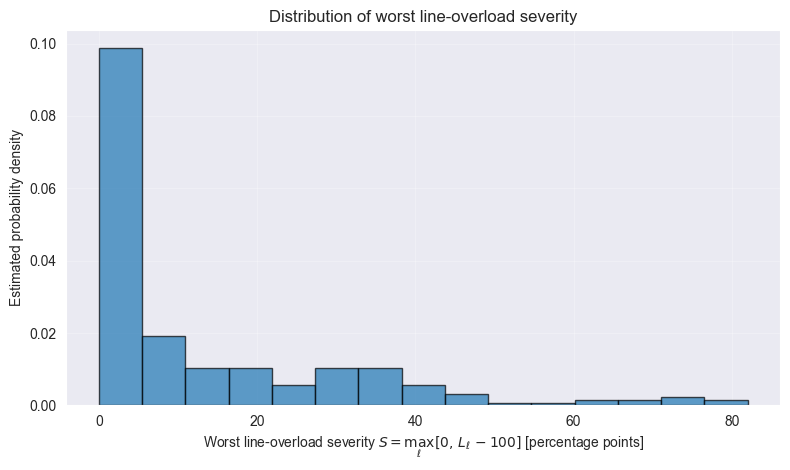

In [18]:
severity = severity_results.loc[
    severity_results["converged"],
    "worst_line_overload_severity",
].dropna().to_numpy()

if severity.size == 0:
    raise RuntimeError("None of the sampled power flows converged.")

fig, ax = plt.subplots(figsize=(8, 4.8))

if np.ptp(severity) < 1e-12:
    # Degenerate empirical distribution: all probability is at one value.
    value = severity[0]

    ax.vlines(
        value,
        ymin=0.0,
        ymax=1.0,
        color="tab:red",
        linewidth=3,
    )
    ax.scatter(
        [value],
        [1.0],
        color="tab:red",
        s=60,
        zorder=3,
    )

    margin = max(1.0, 0.1 * abs(value))
    ax.set_xlim(value - margin, value + margin)
    ax.set_ylim(0.0, 1.15)
    ax.set_ylabel("Probability mass")

    ax.text(
        value,
        1.04,
        f"P(S = {value:.3f}) = 1",
        ha="center",
    )

else:
    number_bins = min(
        15,
        max(5, int(np.ceil(np.sqrt(severity.size)))),
    )

    ax.hist(
        severity,
        bins=number_bins,
        density=True,
        alpha=0.70,
        edgecolor="black",
        color="tab:blue",
    )

    ax.set_ylabel("Estimated probability density")

ax.set_xlabel(
    "Worst line-overload severity "
    r"$S=\max_\ell[0,\,L_\ell-100]$ [percentage points]"
)
ax.set_title("Distribution of worst line-overload severity")
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

# Optional: save the figure as a PDF document.
fig.savefig(
    "worst_line_overload_severity_pdf.pdf",
    bbox_inches="tight",
)


Risk summary
              outages  contingency_probability  expected_severity  risk_score  risk_ci95_lower  risk_ci95_upper  P_overload_given_c  P_voltage_violation_given_c  expected_unsupplied_mw  P_nonconvergence_given_c
case                                                                                                                                                                                                              
Gen 0      [(gen, 0)]                 0.008152           0.270628    0.002206         0.002162         0.002250               0.013                        1.000                     0.0                     0.000
Trafo 0  [(trafo, 0)]                 0.000684           3.143545    0.002152         0.002126         0.002177               0.794                        0.996                     0.0                     0.004
Line 0    [(line, 0)]                 0.000228           0.596730    0.000136         0.000134         0.000138               0.092           

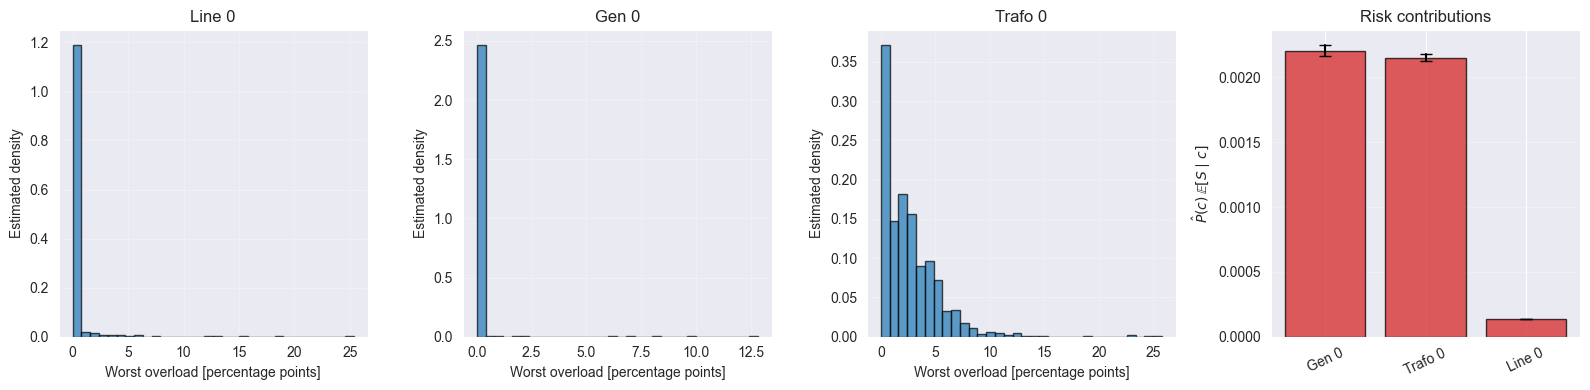

In [20]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandapower as pp
import pandapower.networks as pp_net
import pandapower.topology as top


# ============================================================
# Configuration
# ============================================================

N_SAMPLES, NOISE_LEVEL, SEED = 1_000, 0.05, 42
VMIN, VMAX, VREF = 0.95, 1.05, 0.05
SEVERITY_WEIGHTS = {"line": 1.0, "voltage": 1.0, "unserved": 1.0}
NONCONVERGENCE_SEVERITY = 10.0

# Set p=1.0 for a certain planned outage; p=None estimates it from RELIABILITY.
CASES = {
    "Line 0":  {"outages": [("line", 0)],  "p": None},
    "Gen 0":   {"outages": [("gen", 0)],   "p": None},
    "Trafo 0": {"outages": [("trafo", 0)], "p": None},
}

# Illustrative values only: failures/year and mean repair duration [h].
RELIABILITY = {
    ("line", 0):  (0.20, 10.0),
    ("gen", 0):   (1.50, 48.0),
    ("trafo", 0): (0.05, 120.0),
}


# ============================================================
# Utilities
# ============================================================

def simple_demand_sampler(mean, n_samples=30, noise_level=0.01,
                          fat_tailed=True, seed=42):
    """Sample nonnegative nodal demands around their baseline values."""
    rng = np.random.default_rng(seed)
    shape = (n_samples, len(mean))
    z = rng.standard_t(3, shape) / np.sqrt(3) if fat_tailed else rng.normal(size=shape)
    return np.maximum(np.asarray(mean)[None, :] * (1 + noise_level * z), 0.0)


def apply_outage(net, outage_list):
    """Apply e.g. [('line', 0)], [('gen', 2)] or [('line', 0), ('trafo', 1)]."""
    out = copy.deepcopy(net)
    tables = {"line": out.line, "gen": out.gen, "trafo": out.trafo}

    for element_type, idx in outage_list:
        if element_type not in tables:
            raise ValueError(f"Unsupported type {element_type!r}; use {tuple(tables)}.")
        if idx not in tables[element_type].index:
            raise KeyError(f"{element_type} index {idx} does not exist.")
        tables[element_type].at[idx, "in_service"] = False

    return out


def forced_outage_probability(failure_rate_per_year, repair_time_h):
    """Steady-state component unavailability."""
    x = failure_rate_per_year * repair_time_h / 8760.0
    return x / (1.0 + x)


def contingency_probability(outages):
    """Probability that all listed components are unavailable; independence assumed."""
    return float(np.prod([
        forced_outage_probability(*RELIABILITY[element]) for element in outages
    ]))


def finite_max(x, default=0.0):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(x.max()) if x.size else default


def finite_min(x, default=np.nan):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(x.min()) if x.size else default


# ============================================================
# Baseline OPF and fixed dispatch
# ============================================================

net = pp_net.case24_ieee_rts()

pp.runopp(net, calculate_voltage_angles=True, init="flat",
          delta=1e-8, verbose=False, numba=False)

if not net.OPF_converged:
    raise RuntimeError("Baseline OPF did not converge.")

# Copy only the optimized generator setpoints, not the entire result table.
net.gen.loc[:, "p_mw"] = net.res_gen["p_mw"].to_numpy()
net.gen.loc[:, "vm_pu"] = net.res_gen["vm_pu"].to_numpy()

pp.runpp(net, calculate_voltage_angles=True, init="results",
         enforce_q_lims=True, distributed_slack=False, numba=False)

if not net.converged:
    raise RuntimeError("Baseline fixed-dispatch power flow did not converge.")

NET = copy.deepcopy(net)
BASE_P = NET.load["p_mw"].to_numpy(float)
BASE_Q = NET.load["q_mvar"].to_numpy(float)
FIXED_GEN_P = NET.gen["p_mw"].to_numpy(float)
BASE_GRID_P = float(NET.res_ext_grid["p_mw"].sum())

LOAD_SAMPLES = simple_demand_sampler(
    BASE_P, N_SAMPLES, NOISE_LEVEL, fat_tailed=True, seed=SEED
)


# ============================================================
# Contingency severity evaluation
#
# S = wL max_l[(loading_l/100)-1]+
#   + wV max_b{[VMIN-v_b]+,[v_b-VMAX]+}/VREF
#   + wU P_unsupplied/P_demand
#
# Risk(c) = P(c) E[S | c]
# ============================================================

def evaluate_case(outages):
    template, rows = apply_outage(NET, outages), []

    for scenario, sampled_p in enumerate(LOAD_SAMPLES):
        sc = copy.deepcopy(template)
        sc.load.loc[:, "p_mw"] = sampled_p

        scaling = np.divide(
            sampled_p, BASE_P, out=np.ones_like(sampled_p),
            where=np.abs(BASE_P) > 1e-12
        )
        sc.load.loc[:, "q_mvar"] = BASE_Q * scaling
        sc.gen.loc[:, "p_mw"] = FIXED_GEN_P

        unsupplied_buses = set(top.unsupplied_buses(sc, respect_switches=True))
        mask = sc.load["bus"].isin(unsupplied_buses) & sc.load["in_service"]
        unsupplied_mw = float(sc.load.loc[mask, "p_mw"].sum())
        total_demand_mw = float(sampled_p.sum())

        try:
            pp.runpp(sc, calculate_voltage_angles=True, init="results",
                     enforce_q_lims=True, distributed_slack=False,
                     check_connectivity=True, numba=False)

            if not sc.converged:
                raise pp.LoadflowNotConverged

            loading = sc.res_line["loading_percent"].to_numpy(float)
            voltage = sc.res_bus["vm_pu"].to_numpy(float)
            overload = np.maximum(loading - 100.0, 0.0)
            undervoltage = np.maximum(VMIN - voltage, 0.0)
            overvoltage = np.maximum(voltage - VMAX, 0.0)

            worst_overload = finite_max(overload)
            worst_under = finite_max(undervoltage)
            worst_over = finite_max(overvoltage)

            s_line = worst_overload / 100.0
            s_voltage = max(worst_under, worst_over) / VREF
            s_unserved = unsupplied_mw / max(total_demand_mw, 1e-12)

            severity = (
                SEVERITY_WEIGHTS["line"] * s_line
                + SEVERITY_WEIGHTS["voltage"] * s_voltage
                + SEVERITY_WEIGHTS["unserved"] * s_unserved
            )

            pos = int(np.nanargmax(loading)) if np.any(np.isfinite(loading)) else None
            worst_line = sc.res_line.index[pos] if pos is not None else None

            rows.append({
                "scenario": scenario, "converged": True,
                "demand_mw": total_demand_mw,
                "grid_p_mw": float(sc.res_ext_grid["p_mw"].sum()),
                "grid_delta_mw": float(sc.res_ext_grid["p_mw"].sum()) - BASE_GRID_P,
                "max_line_loading_pct": finite_max(loading),
                "worst_line": worst_line,
                "worst_overload_pctpt": worst_overload,
                "min_voltage_pu": finite_min(voltage),
                "max_voltage_pu": finite_max(voltage, np.nan),
                "undervoltage_pu": worst_under,
                "overvoltage_pu": worst_over,
                "unsupplied_mw": unsupplied_mw,
                "line_severity": s_line,
                "voltage_severity": s_voltage,
                "unserved_severity": s_unserved,
                "severity": severity,
            })

        except pp.LoadflowNotConverged:
            rows.append({
                "scenario": scenario, "converged": False,
                "demand_mw": total_demand_mw,
                "grid_p_mw": np.nan, "grid_delta_mw": np.nan,
                "max_line_loading_pct": np.nan, "worst_line": None,
                "worst_overload_pctpt": np.nan,
                "min_voltage_pu": np.nan, "max_voltage_pu": np.nan,
                "undervoltage_pu": np.nan, "overvoltage_pu": np.nan,
                "unsupplied_mw": unsupplied_mw,
                "line_severity": np.nan, "voltage_severity": np.nan,
                "unserved_severity": unsupplied_mw / max(total_demand_mw, 1e-12),
                "severity": NONCONVERGENCE_SEVERITY,
            })

    return pd.DataFrame(rows).set_index("scenario")


# ============================================================
# Run the three cases and estimate risk
# ============================================================

DETAILS, summary = {}, []

for name, case in CASES.items():
    df = evaluate_case(case["outages"])
    DETAILS[name] = df

    p = case["p"] if case["p"] is not None else contingency_probability(case["outages"])
    s = df["severity"].to_numpy(float)
    mean_s = float(s.mean())
    se_s = float(s.std(ddof=1) / np.sqrt(len(s))) if len(s) > 1 else 0.0
    risk, risk_se = p * mean_s, p * se_s

    summary.append({
        "case": name,
        "outages": case["outages"],
        "contingency_probability": p,
        "expected_severity": mean_s,
        "risk_score": risk,
        "risk_ci95_lower": max(0.0, risk - 1.96 * risk_se),
        "risk_ci95_upper": risk + 1.96 * risk_se,
        "P_overload_given_c": df["worst_overload_pctpt"].fillna(0).gt(0).mean(),
        "P_voltage_violation_given_c": (
            df["undervoltage_pu"].fillna(0).gt(0)
            | df["overvoltage_pu"].fillna(0).gt(0)
        ).mean(),
        "expected_unsupplied_mw": df["unsupplied_mw"].mean(),
        "P_nonconvergence_given_c": 1.0 - df["converged"].mean(),
    })

RISK_SUMMARY = pd.DataFrame(summary).set_index("case").sort_values("risk_score", ascending=False)
ALL_RESULTS = pd.concat(DETAILS, names=["case", "scenario"])

print("\nRisk summary")
print(RISK_SUMMARY.to_string())
print(f"\nTotal selected-contingency risk: {RISK_SUMMARY['risk_score'].sum():.6e}")


# ============================================================
# Plot conditional overload PDFs and risk contributions
# ============================================================

fig, axes = plt.subplots(1, len(DETAILS) + 1, figsize=(4 * (len(DETAILS) + 1), 4))

for ax, (name, df) in zip(axes[:-1], DETAILS.items()):
    x = df["worst_overload_pctpt"].dropna().to_numpy()

    if not len(x):
        ax.text(0.5, 0.5, "No converged cases", ha="center", transform=ax.transAxes)
    elif np.ptp(x) < 1e-12:
        ax.vlines(x[0], 0, 1, color="tab:red", lw=3)
        ax.scatter(x[0], 1, color="tab:red")
        margin = max(1.0, 0.1 * abs(x[0]))
        ax.set(xlim=(x[0] - margin, x[0] + margin), ylim=(0, 1.15),
               ylabel="Probability mass")
    else:
        ax.hist(x, bins=max(5, int(np.ceil(np.sqrt(len(x))))),
                density=True, alpha=0.7, edgecolor="black")
        ax.set_ylabel("Estimated density")

    ax.set(title=name, xlabel="Worst overload [percentage points]")
    ax.grid(alpha=0.25)

risk = RISK_SUMMARY["risk_score"]
err = np.vstack([
    risk - RISK_SUMMARY["risk_ci95_lower"],
    RISK_SUMMARY["risk_ci95_upper"] - risk,
])

axes[-1].bar(risk.index, risk, yerr=err, capsize=4,
             color="tab:red", alpha=0.75, edgecolor="black")
axes[-1].set(title="Risk contributions",
             ylabel=r"$\hat P(c)\,\mathbb{E}[S\mid c]$")
axes[-1].tick_params(axis="x", rotation=25)
axes[-1].grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()
fig.savefig("contingency_severity_and_risk.pdf", bbox_inches="tight")


WEEKLY RISK SUMMARY
         mean_probability  max_probability  mean_severity  max_severity  probability_weighted_severity  weekly_risk  P_overload_given_case  P_voltage_violation_given_case  expected_unsupplied_mw  nonconvergence_frequency
case                                                                                                                                                                                                                        
Gen 0            0.008245         0.009716       0.482603      1.181847                       0.484039     0.670441               0.250000                        1.000000                     0.0                  0.000000
Trafo 0          0.000721         0.001189       4.350278     10.000000                       4.404765     0.533216               0.630952                        0.797619                     0.0                  0.202381
Line 0           0.000309         0.001355       0.743515      1.660410                       0

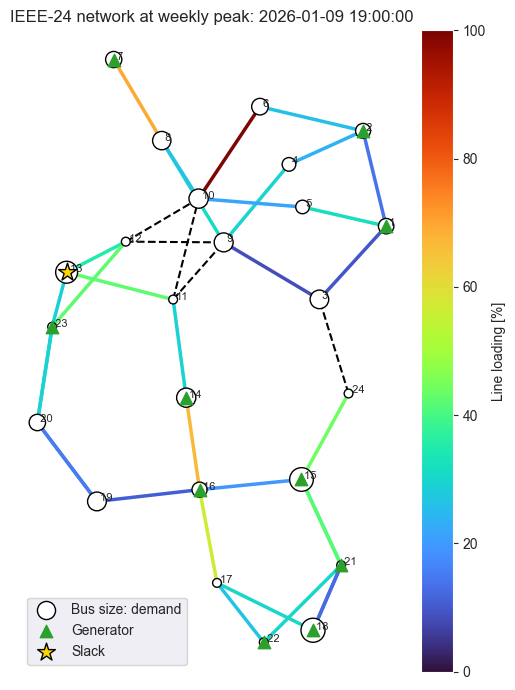

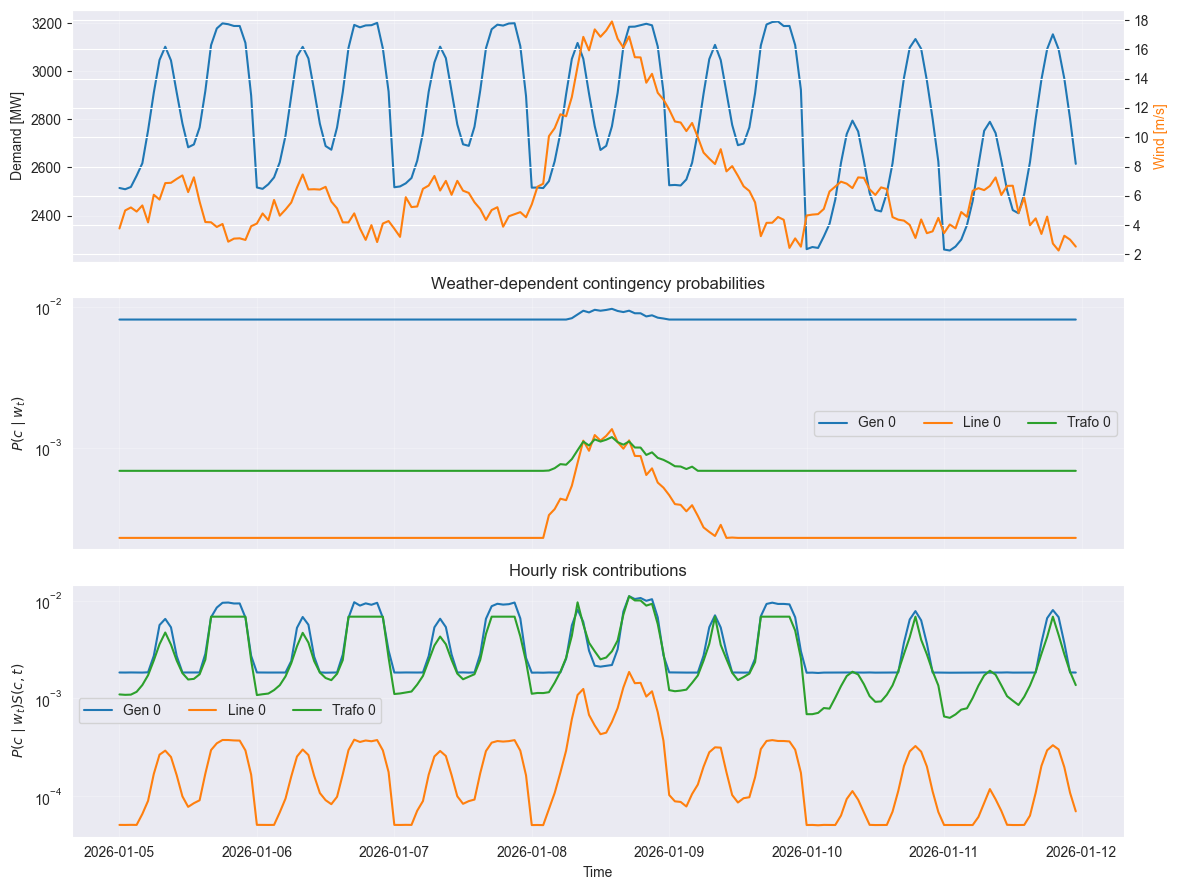

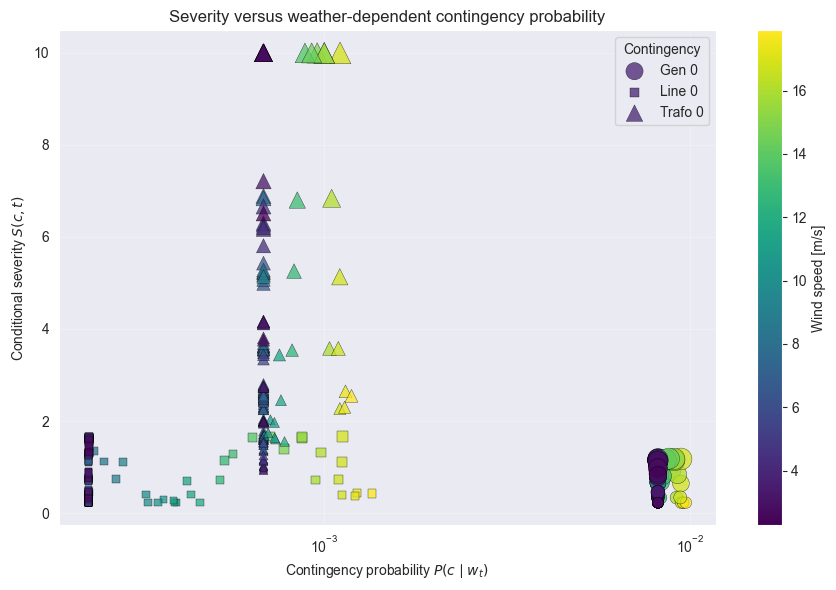

In [21]:
import copy, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import pandapower as pp
import pandapower.networks as pp_net
import pandapower.topology as top


# ============================================================
# Configuration
# ============================================================

SEED, VMIN, VMAX, VREF = 42, 0.95, 1.05, 0.05
W = {"line": 1.0, "voltage": 1.0, "unserved": 1.0}
NONCONVERGENCE_SEVERITY = 10.0
TIME = pd.date_range("2026-01-05", periods=168, freq="h")

# p=None: estimate weather-dependent probability.
# p=1.0: certain planned outage during every analyzed hour.
CASES = {
    "Line 0":  {"outages": [("line", 0)],  "p": None},
    "Gen 0":   {"outages": [("gen", 0)],   "p": None},
    "Trafo 0": {"outages": [("trafo", 0)], "p": None},
}

# Illustrative model: base failures/year, repair time [h],
# wind threshold [m/s], and exponential wind sensitivity.
FAILURE_MODEL = {
    "line":  {"lambda0": 0.20, "repair_h": 10,  "wind0": 8,  "beta": 0.18},
    "gen":   {"lambda0": 1.50, "repair_h": 48,  "wind0": 12, "beta": 0.03},
    "trafo": {"lambda0": 0.05, "repair_h": 120, "wind0": 10, "beta": 0.07},
}


# ============================================================
# Utilities
# ============================================================

def apply_outage(net, outages):
    """Apply [('line',0)], [('gen',2)] or a multi-component outage."""
    out = copy.deepcopy(net)
    tables = {"line": out.line, "gen": out.gen, "trafo": out.trafo}
    for kind, idx in outages:
        if kind not in tables:
            raise ValueError(f"Unsupported type {kind!r}; use {tuple(tables)}.")
        if idx not in tables[kind].index:
            raise KeyError(f"{kind} index {idx} does not exist.")
        tables[kind].at[idx, "in_service"] = False
    return out


def component_probability(kind, wind):
    """
    Weather-dependent forced unavailability:
      lambda(t) = lambda0 exp(beta [wind-wind0]+)
      q(t) = lambda(t) r / (8760 + lambda(t) r)
    """
    m = FAILURE_MODEL[kind]
    lam = m["lambda0"] * np.exp(m["beta"] * np.maximum(wind - m["wind0"], 0))
    q = lam * m["repair_h"] / (8760 + lam * m["repair_h"])
    return q, lam


def contingency_probability(outages, wind):
    """Joint unavailability, assuming independent component outages."""
    p = np.ones_like(np.asarray(wind, float))
    for kind, _ in outages:
        p *= component_probability(kind, wind)[0]
    return p


def fmax(x, default=0.0):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return float(x.max()) if x.size else default


def fmin(x, default=np.nan):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return float(x.min()) if x.size else default


# ============================================================
# Network and base operating state
# ============================================================

BASE = pp_net.case24_ieee_rts()
BASE_P = BASE.load["p_mw"].to_numpy(float)
BASE_Q = BASE.load["q_mvar"].to_numpy(float)

# Synthetic one-week hourly demand and weather.
rng = np.random.default_rng(SEED)
h = np.arange(len(TIME))
hod = TIME.hour.to_numpy()
weekend = np.where(TIME.dayofweek.to_numpy() >= 5, 0.90, 1.0)

daily = (
    0.72
    + 0.17 * np.exp(-0.5 * ((hod - 8) / 2.2) ** 2)
    + 0.28 * np.exp(-0.5 * ((hod - 19) / 3.0) ** 2)
)
load_multiplier = np.clip(daily * weekend / np.mean(daily * weekend), 0.72, 1.12)
nodal_noise = 1 + 0.01 * rng.standard_t(3, (len(TIME), len(BASE_P))) / np.sqrt(3)
WEEK_P = np.maximum(BASE_P[None, :] * load_multiplier[:, None] * nodal_noise, 0)
WEEK_Q = BASE_Q[None, :] * np.divide(
    WEEK_P, BASE_P, out=np.ones_like(WEEK_P), where=np.abs(BASE_P) > 1e-12
)

# Synthetic wind forecast with a storm around the fourth day.
storm = 12 * np.exp(-0.5 * ((h - 88) / 9) ** 2)
wind = np.maximum(5 + 1.8 * np.sin(2 * np.pi * (hod - 3) / 24)
                  + storm + rng.normal(0, 0.6, len(TIME)), 0)

WEATHER = pd.DataFrame({
    "wind_m_s": wind,
    "line_failure_rate_per_year": component_probability("line", wind)[1],
}, index=TIME)


# ============================================================
# Hourly OPF + contingency analysis
#
# S = wL max[(loading/100)-1]+
#   + wV max{[VMIN-v]+,[v-VMAX]+}/VREF
#   + wU P_unsupplied/P_demand
#
# R(c,t) = P(c|weather_t) S(c,t)
# ============================================================

rows, peak_net = [], None
peak_hour = int(np.argmax(WEEK_P.sum(axis=1)))

for t, timestamp in enumerate(TIME):

    # Hourly optimal baseline dispatch.
    operating_net = copy.deepcopy(BASE)
    operating_net.load.loc[:, "p_mw"] = WEEK_P[t]
    operating_net.load.loc[:, "q_mvar"] = WEEK_Q[t]

    pp.runopp(operating_net, calculate_voltage_angles=True, init="flat",
              delta=1e-8, verbose=False, numba=False)

    if not operating_net.OPF_converged:
        raise RuntimeError(f"OPF failed at {timestamp}.")

    operating_net.gen.loc[:, "p_mw"] = operating_net.res_gen["p_mw"].to_numpy()
    operating_net.gen.loc[:, "vm_pu"] = operating_net.res_gen["vm_pu"].to_numpy()

    pp.runpp(operating_net, calculate_voltage_angles=True, init="results",
             enforce_q_lims=True, distributed_slack=False, numba=False)

    if not operating_net.converged:
        raise RuntimeError(f"Baseline PF failed at {timestamp}.")

    if t == peak_hour:
        peak_net = copy.deepcopy(operating_net)

    fixed_gen_p = operating_net.gen["p_mw"].to_numpy(float)
    base_grid_p = float(operating_net.res_ext_grid["p_mw"].sum())

    for name, case in CASES.items():
        sc = apply_outage(operating_net, case["outages"])
        sc.gen.loc[:, "p_mw"] = fixed_gen_p

        unsupplied_buses = set(top.unsupplied_buses(sc, respect_switches=True))
        mask = sc.load["bus"].isin(unsupplied_buses) & sc.load["in_service"]
        unsupplied_mw = float(sc.load.loc[mask, "p_mw"].sum())
        total_demand = float(sc.load["p_mw"].sum())

        p_c = (
            float(case["p"])
            if case["p"] is not None
            else float(contingency_probability(case["outages"], np.array([wind[t]]))[0])
        )

        try:
            pp.runpp(sc, calculate_voltage_angles=True, init="results",
                     enforce_q_lims=True, distributed_slack=False,
                     check_connectivity=True, numba=False)

            if not sc.converged:
                raise pp.LoadflowNotConverged

            loading = sc.res_line["loading_percent"].to_numpy(float)
            voltage = sc.res_bus["vm_pu"].to_numpy(float)
            overload = np.maximum(loading - 100, 0)
            under, over = np.maximum(VMIN - voltage, 0), np.maximum(voltage - VMAX, 0)

            worst_overload = fmax(overload)
            s_line = worst_overload / 100
            s_voltage = max(fmax(under), fmax(over)) / VREF
            s_unserved = unsupplied_mw / max(total_demand, 1e-12)
            severity = W["line"]*s_line + W["voltage"]*s_voltage + W["unserved"]*s_unserved

            pos = int(np.nanargmax(loading)) if np.any(np.isfinite(loading)) else None
            worst_line = sc.res_line.index[pos] if pos is not None else None

            row = {
                "time": timestamp, "case": name, "converged": True,
                "load_multiplier": load_multiplier[t], "demand_mw": total_demand,
                "wind_m_s": wind[t], "contingency_probability": p_c,
                "max_loading_pct": fmax(loading), "worst_line": worst_line,
                "worst_overload_pctpt": worst_overload,
                "min_voltage_pu": fmin(voltage), "max_voltage_pu": fmax(voltage, np.nan),
                "unsupplied_mw": unsupplied_mw,
                "line_severity": s_line, "voltage_severity": s_voltage,
                "unserved_severity": s_unserved, "severity": severity,
                "risk": p_c * severity,
                "grid_delta_mw": float(sc.res_ext_grid["p_mw"].sum()) - base_grid_p,
            }

        except pp.LoadflowNotConverged:
            row = {
                "time": timestamp, "case": name, "converged": False,
                "load_multiplier": load_multiplier[t], "demand_mw": total_demand,
                "wind_m_s": wind[t], "contingency_probability": p_c,
                "max_loading_pct": np.nan, "worst_line": None,
                "worst_overload_pctpt": np.nan,
                "min_voltage_pu": np.nan, "max_voltage_pu": np.nan,
                "unsupplied_mw": unsupplied_mw,
                "line_severity": np.nan, "voltage_severity": np.nan,
                "unserved_severity": unsupplied_mw/max(total_demand, 1e-12),
                "severity": NONCONVERGENCE_SEVERITY,
                "risk": p_c * NONCONVERGENCE_SEVERITY,
                "grid_delta_mw": np.nan,
            }

        rows.append(row)

RESULTS = pd.DataFrame(rows).set_index("time")


# ============================================================
# Weekly risk summary
# ============================================================

SUMMARY = RESULTS.groupby("case").apply(
    lambda x: pd.Series({
        "mean_probability": x["contingency_probability"].mean(),
        "max_probability": x["contingency_probability"].max(),
        "mean_severity": x["severity"].mean(),
        "max_severity": x["severity"].max(),
        "probability_weighted_severity":
            x["risk"].sum() / max(x["contingency_probability"].sum(), 1e-15),
        "weekly_risk": x["risk"].sum(),
        "P_overload_given_case": x["worst_overload_pctpt"].fillna(0).gt(0).mean(),
        "P_voltage_violation_given_case": (
            x["min_voltage_pu"].fillna(VMIN).lt(VMIN)
            | x["max_voltage_pu"].fillna(VMAX).gt(VMAX)
        ).mean(),
        "expected_unsupplied_mw": x["unsupplied_mw"].mean(),
        "nonconvergence_frequency": 1 - x["converged"].mean(),
    }),
    include_groups=False,
).sort_values("weekly_risk", ascending=False)

print("\nWEEKLY RISK SUMMARY")
print(SUMMARY.to_string())
print(f"\nTotal selected-contingency weekly risk: {SUMMARY['weekly_risk'].sum():.6e}")


# ============================================================
# 1. Network map at the peak-load hour
# ============================================================

def coordinates(net):
    xy = {}
    for bus, geo in net.bus["geo"].items():
        g = json.loads(geo) if isinstance(geo, str) else geo
        xy[bus] = np.asarray(g["coordinates"], float)
    return xy


xy = coordinates(peak_net)
line_segments = [[xy[r.from_bus], xy[r.to_bus]] for _, r in peak_net.line.iterrows()]
line_loading = peak_net.res_line["loading_percent"].to_numpy(float)

fig, ax = plt.subplots(figsize=(9, 7))
norm = Normalize(0, max(100, np.nanmax(line_loading)))
lines = LineCollection(line_segments, cmap="turbo", norm=norm, linewidths=2.5)
lines.set_array(line_loading)
ax.add_collection(lines)

for _, tr in peak_net.trafo.iterrows():
    ax.plot(*np.vstack([xy[tr.hv_bus], xy[tr.lv_bus]]).T,
            color="black", linestyle="--", linewidth=1.5)

bus_load = peak_net.load.groupby("bus")["p_mw"].sum().reindex(
    peak_net.bus.index, fill_value=0
)
bus_xy = np.vstack([xy[b] for b in peak_net.bus.index])
sizes = 40 + 260 * bus_load.to_numpy() / max(bus_load.max(), 1)

ax.scatter(bus_xy[:, 0], bus_xy[:, 1], s=sizes, color="white",
           edgecolor="black", zorder=3, label="Bus size: demand")

gen_buses = peak_net.gen.loc[peak_net.gen.in_service, "bus"].unique()
ext_buses = peak_net.ext_grid.loc[peak_net.ext_grid.in_service, "bus"].unique()
ax.scatter(*np.vstack([xy[b] for b in gen_buses]).T, marker="^",
           s=80, color="tab:green", zorder=4, label="Generator")
ax.scatter(*np.vstack([xy[b] for b in ext_buses]).T, marker="*",
           s=180, color="gold", edgecolor="black", zorder=5, label="Slack")

for b in peak_net.bus.index:
    ax.text(*xy[b], f" {peak_net.bus.at[b, 'name']}", fontsize=8)

fig.colorbar(lines, ax=ax, pad=0.02, label="Line loading [%]")
ax.set_title(f"IEEE-24 network at weekly peak: {TIME[peak_hour]}")
ax.set_aspect("equal"); ax.autoscale(); ax.axis("off"); ax.legend(loc="best")
fig.tight_layout()
fig.savefig("weekly_network_map.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 2. Weekly loads, weather probabilities and risk
# ============================================================

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

ax2 = ax[0].twinx()
ax[0].plot(TIME, WEEK_P.sum(axis=1), color="tab:blue", label="Demand")
ax2.plot(TIME, wind, color="tab:orange", label="Wind")
ax[0].set_ylabel("Demand [MW]")
ax2.set_ylabel("Wind [m/s]", color="tab:orange")
ax[0].grid(alpha=0.25)

for name, df in RESULTS.groupby("case"):
    ax[1].semilogy(df.index, df["contingency_probability"], label=name)
    ax[2].semilogy(df.index, np.maximum(df["risk"], 1e-16), label=name)

ax[1].set_ylabel(r"$P(c\mid w_t)$")
ax[1].set_title("Weather-dependent contingency probabilities")
ax[2].set_ylabel(r"$P(c\mid w_t)S(c,t)$")
ax[2].set_title("Hourly risk contributions")
ax[2].set_xlabel("Time")

for a in ax[1:]:
    a.grid(alpha=0.25)
    a.legend(ncol=3)

fig.tight_layout()
fig.savefig("weekly_load_weather_risk.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 3. Severity versus probability
#    Point size = risk contribution; color = wind speed
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))
norm = Normalize(RESULTS["wind_m_s"].min(), RESULTS["wind_m_s"].max())
markers = ["o", "s", "^", "D", "P"]
max_risk = max(RESULTS["risk"].max(), 1e-15)

for marker, (name, df) in zip(markers, RESULTS.groupby("case")):
    sizes = 25 + 220 * df["risk"].to_numpy() / max_risk
    ax.scatter(
        df["contingency_probability"], df["severity"],
        c=df["wind_m_s"], cmap="viridis", norm=norm,
        s=sizes, marker=marker, alpha=0.75,
        edgecolor="black", linewidth=0.3, label=name,
    )

ax.set_xscale("log")
ax.set_xlabel(r"Contingency probability $P(c\mid w_t)$")
ax.set_ylabel(r"Conditional severity $S(c,t)$")
ax.set_title("Severity versus weather-dependent contingency probability")
ax.grid(alpha=0.25)
ax.legend(title="Contingency")
fig.colorbar(ScalarMappable(norm=norm, cmap="viridis"),
             ax=ax, label="Wind speed [m/s]")
fig.tight_layout()
fig.savefig("severity_vs_probability.pdf", bbox_inches="tight")
plt.show()